In [3]:
# =============================================================================
# CELL 1: Setup Kaggle API and Download Dataset
# =============================================================================

import os
import json

# Install required packages
!pip install -q kaggle
!pip install -q efficientnet

# Create kaggle directory
!mkdir -p ~/.kaggle

# Write kaggle.json credentials directly
kaggle_credentials = {
    "username": "YOUR_KAGGLE_USERNAME",
    "key": "YOUR_KAGGLE_KEY"
}

kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")
with open(kaggle_json_path, "w") as f:
    json.dump(kaggle_credentials, f)

# Set correct permissions
!chmod 600 ~/.kaggle/kaggle.json

# Verify Kaggle setup
!kaggle --version

Kaggle CLI 2.0.2


In [4]:
# =============================================================================
# CELL 2: Download the Diabetic Retinopathy Dataset from Kaggle
# =============================================================================

# Download the dataset (using the popular diabetic retinopathy dataset)
# Option 1: Original competition dataset (very large ~80GB)
# !kaggle competitions download -c diabetic-retinopathy-detection

# Option 2: Smaller preprocessed dataset (recommended for Colab)
!kaggle datasets download -d sovitrath/diabetic-retinopathy-224x224-2019-data

# Unzip the dataset
!unzip -q diabetic-retinopathy-224x224-2019-data.zip -d ./diabetic_retinopathy_data

# List the contents
!ls ./diabetic_retinopathy_data

Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data
License(s): CC0-1.0
100% 238M/238M [00:01<00:00, 185MB/s] 

colored_images	train.csv


In [5]:
# =============================================================================
# CELL 3: Alternative Dataset Option (Gaussian Filtered)
# =============================================================================

# If the above dataset doesn't work, try this alternative:
# !kaggle datasets download -d tanlikesmath/diabetic-retinopathy-resized

# Or this preprocessed version:
# !kaggle datasets download -d mariaherrerot/aptos2019blindnessdetection

# Uncomment and run if needed:
# !unzip -q diabetic-retinopathy-resized.zip -d ./diabetic_retinopathy_data

In [6]:
# =============================================================================
# CELL 4: Import Libraries
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3, ResNet50, DenseNet121
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             cohen_kappa_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


In [7]:
# =============================================================================
# CELL 5: Configuration and Hyperparameters
# =============================================================================

class Config:
    # Data paths - Update these based on your dataset structure
    BASE_DIR = './diabetic_retinopathy_data'

    # Image settings
    IMG_SIZE = 224
    CHANNELS = 3
    INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, CHANNELS)

    # Training settings
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 1e-4

    # Number of classes (0: No DR, 1: Mild, 2: Moderate, 3: Severe, 4: Proliferative)
    NUM_CLASSES = 5
    CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative_DR']

    # Model settings
    DROPOUT_RATE = 0.3

config = Config()
print("Configuration loaded successfully!")

Configuration loaded successfully!


In [8]:
# =============================================================================
# CELL 6: Explore Dataset Structure
# =============================================================================

def explore_dataset(base_dir):
    """Explore the dataset structure and find images."""
    print(f"Exploring: {base_dir}")
    print("-" * 50)

    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

        # Only show first 5 files
        sub_indent = ' ' * 2 * (level + 1)
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            print(f'{sub_indent}Images: {len(image_files)} files')
            for f in image_files[:3]:
                print(f'{sub_indent}  - {f}')
            if len(image_files) > 3:
                print(f'{sub_indent}  ... and {len(image_files)-3} more')

        if level > 2:
            break

explore_dataset(config.BASE_DIR)

Exploring: ./diabetic_retinopathy_data
--------------------------------------------------
diabetic_retinopathy_data/
  colored_images/
    Mild/
      Images: 370 files
        - a8582e346df0.png
        - 545df1bbcd61.png
        - ca63fe4f4b52.png
        ... and 367 more
    Proliferate_DR/
      Images: 295 files
        - 10fca1abf338.png
        - 4dd71fc7f22b.png
        - b3819a805dca.png
        ... and 292 more
    No_DR/
      Images: 1805 files
        - daad7b617f21.png
        - 9d75de31f1b8.png
        - ee3f5cf52188.png
        ... and 1802 more
    Severe/
      Images: 193 files
        - bf8092e4001d.png
        - 0f882877bf13.png
        - e32a359be36d.png
        ... and 190 more
    Moderate/
      Images: 999 files
        - e83d315d8f98.png
        - 44e0d56e9d42.png
        - 5d024177e214.png
        ... and 996 more


In [9]:
# =============================================================================
# CELL 7: Data Loading and Preprocessing Functions
# =============================================================================

def crop_image_from_gray(img, tol=7):
    """Crop black borders from retinal images."""
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        check_shape = img[:,:,0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if check_shape == 0:
            return img
        else:
            img1 = img[:,:,0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:,:,1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:,:,2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def apply_ben_graham_preprocessing(img, sigmaX=10):
    """Apply Ben Graham's preprocessing method."""
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (config.IMG_SIZE, config.IMG_SIZE))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigmaX), -4, 128)
    return img

def load_and_preprocess_image(image_path, apply_ben_graham=False):
    """Load and preprocess a single image."""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None

        if apply_ben_graham:
            img = apply_ben_graham_preprocessing(img)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (config.IMG_SIZE, config.IMG_SIZE))

        img = img.astype(np.float32) / 255.0
        return img
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
        return None

print("Preprocessing functions defined!")

Preprocessing functions defined!


In [10]:
# =============================================================================
# CELL 8: Create DataFrame from Dataset
# =============================================================================

def create_dataframe_from_folders(base_dir):
    """Create a DataFrame from folder structure where each folder is a class."""
    data = []

    # Check if train folder exists
    train_dir = os.path.join(base_dir, 'train')
    if os.path.exists(train_dir):
        base_dir = train_dir

    # Look for colored_images or similar folders
    for subdir in ['colored_images', 'gaussian_filtered_images', 'images', '']:
        check_dir = os.path.join(base_dir, subdir) if subdir else base_dir
        if os.path.exists(check_dir):
            # Check if this contains class folders
            for class_folder in os.listdir(check_dir):
                class_path = os.path.join(check_dir, class_folder)
                if os.path.isdir(class_path):
                    # Check if folder contains images
                    images = [f for f in os.listdir(class_path)
                             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                    if images:
                        for img_name in images:
                            img_path = os.path.join(class_path, img_name)
                            data.append({
                                'image_path': img_path,
                                'label': class_folder,
                                'filename': img_name
                            })

    if not data:
        print("No images found in standard folder structure. Trying CSV approach...")
        return None

    df = pd.DataFrame(data)
    return df

def create_dataframe_from_csv(base_dir):
    """Create DataFrame from CSV file if available."""
    csv_files = []
    for root, dirs, files in os.walk(base_dir):
        for f in files:
            if f.endswith('.csv'):
                csv_files.append(os.path.join(root, f))

    if not csv_files:
        return None

    print(f"Found CSV files: {csv_files}")

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        print(f"\nCSV: {csv_file}")
        print(f"Columns: {df.columns.tolist()}")
        print(f"Shape: {df.shape}")
        print(df.head())

    return df, csv_files

# Try to create DataFrame
df = create_dataframe_from_folders(config.BASE_DIR)

if df is not None:
    print(f"\nDataFrame created from folders!")
    print(f"Total images: {len(df)}")
    print(f"\nClass distribution:")
    print(df['label'].value_counts())
else:
    result = create_dataframe_from_csv(config.BASE_DIR)
    if result:
        df, csv_files = result


DataFrame created from folders!
Total images: 3662

Class distribution:
label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


In [11]:
# =============================================================================
# CELL 9: Prepare Labels and Handle Class Mapping (FIXED)
# =============================================================================

def prepare_labels(df):
    """Map string labels to numeric values with proper error handling."""

    print("Original labels found:", df['label'].unique())
    print("Label value counts:\n", df['label'].value_counts())

    # Clean the labels first - remove any whitespace
    df['label'] = df['label'].astype(str).str.strip()

    # Define comprehensive label mapping
    label_mapping = {
        # Standard naming conventions
        'No_DR': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Proliferative_DR': 4,
        'No DR': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Proliferative DR': 4,
        'no_dr': 0, 'mild': 1, 'moderate': 2, 'severe': 3, 'proliferative_dr': 4,
        'NO_DR': 0, 'MILD': 1, 'MODERATE': 2, 'SEVERE': 3, 'PROLIFERATIVE_DR': 4,
        # Numeric strings
        '0': 0, '1': 1, '2': 2, '3': 3, '4': 4,
        # Float strings (in case)
        '0.0': 0, '1.0': 1, '2.0': 2, '3.0': 3, '4.0': 4,
    }

    # Try mapping first
    df['label_numeric'] = df['label'].map(label_mapping)

    # Check for unmapped values
    unmapped_mask = df['label_numeric'].isna()
    unmapped_count = unmapped_mask.sum()

    if unmapped_count > 0:
        print(f"\n⚠️ Found {unmapped_count} unmapped labels")
        print("Unmapped values:", df.loc[unmapped_mask, 'label'].unique())

        # Try to convert unmapped values directly to numeric
        for idx in df[unmapped_mask].index:
            try:
                # Try direct numeric conversion
                val = df.loc[idx, 'label']
                numeric_val = int(float(val))
                if 0 <= numeric_val <= 4:
                    df.loc[idx, 'label_numeric'] = numeric_val
            except (ValueError, TypeError):
                pass

    # Remove any remaining rows with NaN labels
    initial_count = len(df)
    df = df.dropna(subset=['label_numeric'])
    removed_count = initial_count - len(df)

    if removed_count > 0:
        print(f"\n⚠️ Removed {removed_count} rows with invalid labels")

    # Convert to integer
    df['label_numeric'] = df['label_numeric'].astype(int)

    # Validate labels are in expected range
    valid_mask = df['label_numeric'].isin([0, 1, 2, 3, 4])
    if not valid_mask.all():
        invalid_labels = df.loc[~valid_mask, 'label_numeric'].unique()
        print(f"\n⚠️ Found invalid numeric labels: {invalid_labels}")
        df = df[valid_mask]

    print(f"\n✅ Label mapping completed!")
    print(f"Final dataset size: {len(df)}")
    print(f"Unique numeric labels: {sorted(df['label_numeric'].unique())}")

    return df

# Apply the fixed label preparation
if df is not None:
    df = prepare_labels(df)

    print("\n" + "=" * 50)
    print("FINAL CLASS DISTRIBUTION")
    print("=" * 50)

    class_dist = df['label_numeric'].value_counts().sort_index()
    for class_idx, count in class_dist.items():
        class_name = config.CLASS_NAMES[class_idx] if class_idx < len(config.CLASS_NAMES) else f"Class_{class_idx}"
        percentage = count / len(df) * 100
        print(f"  {class_idx} - {class_name}: {count} ({percentage:.1f}%)")

    print(f"\nTotal samples: {len(df)}")
else:
    print("❌ DataFrame is None. Please check Cell 8.")

Original labels found: ['Mild' 'Proliferate_DR' 'No_DR' 'Severe' 'Moderate']
Label value counts:
 label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64

⚠️ Found 295 unmapped labels
Unmapped values: ['Proliferate_DR']

⚠️ Removed 295 rows with invalid labels

✅ Label mapping completed!
Final dataset size: 3367
Unique numeric labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

FINAL CLASS DISTRIBUTION
  0 - No_DR: 1805 (53.6%)
  1 - Mild: 370 (11.0%)
  2 - Moderate: 999 (29.7%)
  3 - Severe: 193 (5.7%)

Total samples: 3367


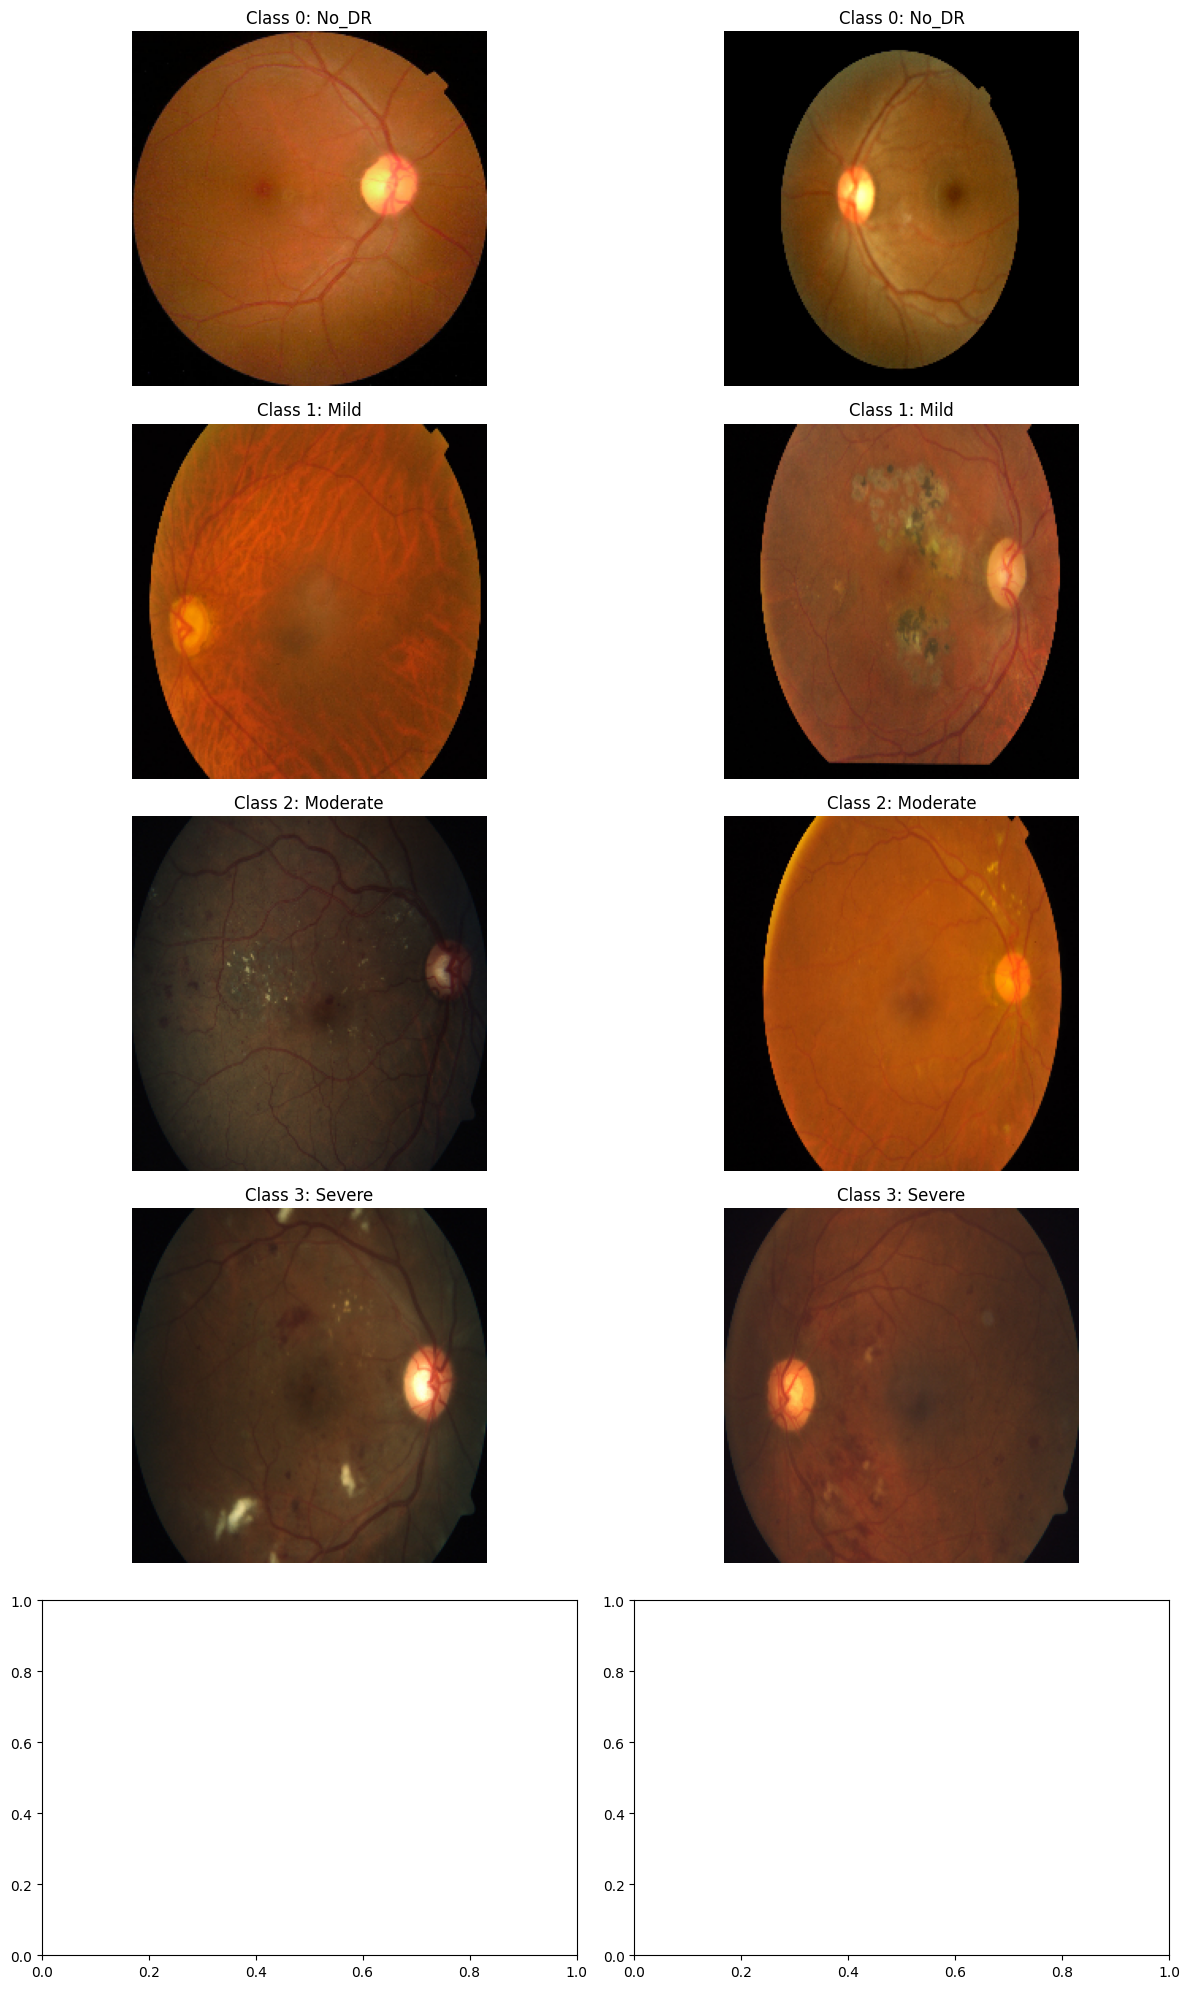

In [12]:
# =============================================================================
# CELL 10: Visualize Sample Images
# =============================================================================

def visualize_samples(df, n_samples=2):
    """Visualize sample images from each class."""
    fig, axes = plt.subplots(config.NUM_CLASSES, n_samples, figsize=(12, 20))

    for class_idx in range(config.NUM_CLASSES):
        class_df = df[df['label_numeric'] == class_idx]
        if len(class_df) == 0:
            continue

        samples = class_df.sample(min(n_samples, len(class_df)))

        for idx, (_, row) in enumerate(samples.iterrows()):
            img = load_and_preprocess_image(row['image_path'])
            if img is not None:
                axes[class_idx, idx].imshow(img)
                axes[class_idx, idx].set_title(f"Class {class_idx}: {config.CLASS_NAMES[class_idx]}")
                axes[class_idx, idx].axis('off')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

if df is not None:
    visualize_samples(df)

In [13]:
# =============================================================================
# CELL 11: Split Data into Train, Validation, and Test Sets
# =============================================================================

def split_data(df, test_size=0.2, val_size=0.1):
    """Split data into train, validation, and test sets with stratification."""

    # First split: train+val and test
    train_val_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df['label_numeric'],
        random_state=42
    )

    # Second split: train and val
    relative_val_size = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=relative_val_size,
        stratify=train_val_df['label_numeric'],
        random_state=42
    )

    print(f"Training set: {len(train_df)} images")
    print(f"Validation set: {len(val_df)} images")
    print(f"Test set: {len(test_df)} images")

    return train_df, val_df, test_df

if df is not None:
    train_df, val_df, test_df = split_data(df)

    # Verify class distribution
    print("\nClass distribution in training set:")
    print(train_df['label_numeric'].value_counts().sort_index())

Training set: 2356 images
Validation set: 337 images
Test set: 674 images

Class distribution in training set:
label_numeric
0    1263
1     259
2     699
3     135
Name: count, dtype: int64


In [14]:
# =============================================================================
# CELL 12: Create Data Generators
# =============================================================================

def create_data_generators(train_df, val_df, test_df):
    """Create ImageDataGenerator for training with augmentation."""

    # Training data augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='constant',
        cval=0
    )

    # Validation and test - only rescaling
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    # Create generators
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='image_path',
        y_col='label_numeric',
        target_size=(config.IMG_SIZE, config.IMG_SIZE),
        batch_size=config.BATCH_SIZE,
        class_mode='raw',
        shuffle=True
    )

    val_generator = val_test_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='image_path',
        y_col='label_numeric',
        target_size=(config.IMG_SIZE, config.IMG_SIZE),
        batch_size=config.BATCH_SIZE,
        class_mode='raw',
        shuffle=False
    )

    test_generator = val_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='image_path',
        y_col='label_numeric',
        target_size=(config.IMG_SIZE, config.IMG_SIZE),
        batch_size=config.BATCH_SIZE,
        class_mode='raw',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

if df is not None:
    train_gen, val_gen, test_gen = create_data_generators(train_df, val_df, test_df)
    print("Data generators created successfully!")

Found 2356 validated image filenames.
Found 337 validated image filenames.
Found 674 validated image filenames.
Data generators created successfully!


In [15]:
# =============================================================================
# CELL 13: Compute Class Weights for Imbalanced Data
# =============================================================================

def compute_class_weights(df):
    """Compute class weights to handle class imbalance."""
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(df['label_numeric']),
        y=df['label_numeric']
    )

    class_weight_dict = dict(enumerate(class_weights))
    print("Class weights:", class_weight_dict)

    return class_weight_dict

if df is not None:
    class_weights = compute_class_weights(train_df)

Class weights: {0: np.float64(0.4663499604117181), 1: np.float64(2.2741312741312742), 2: np.float64(0.8426323319027181), 3: np.float64(4.362962962962963)}


In [16]:
# =============================================================================
# CELL 14: Build the Model Architecture
# =============================================================================

def build_efficientnet_model(input_shape, num_classes, dropout_rate=0.3):
    """Build EfficientNetB3 based model for DR classification."""

    # Load pre-trained EfficientNetB3
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model layers initially
    base_model.trainable = False

    # Build the model
    inputs = layers.Input(shape=input_shape)

    # Data augmentation layers
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)

    # Base model
    x = base_model(x, training=False)

    # Custom head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

def build_custom_cnn_model(input_shape, num_classes, dropout_rate=0.3):
    """Build a custom CNN model (lighter alternative)."""

    model = models.Sequential([
        # Input
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully connected layers
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Build the model
print("Building EfficientNetB3 model...")
model, base_model = build_efficientnet_model(
    config.INPUT_SHAPE,
    config.NUM_CLASSES,
    config.DROPOUT_RATE
)

model.summary()

Building EfficientNetB3 model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,711,284 (44.68 MB)

 Trainable params: 923,653 (3.52 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

In [17]:
# =============================================================================
# CELL 15: Custom Metrics and Loss Functions
# =============================================================================

class QuadraticWeightedKappa(tf.keras.metrics.Metric):
    """Custom metric for Quadratic Weighted Kappa score."""

    def __init__(self, num_classes, name='qwk', **kwargs):
        super(QuadraticWeightedKappa, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.y_true = []
        self.y_pred = []

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1)
        y_pred = tf.cast(y_pred, tf.int32)

        self.y_true.append(y_true)
        self.y_pred.append(y_pred)

    def result(self):
        return tf.constant(0.0)  # Placeholder - compute in callback

    def reset_state(self):
        self.y_true = []
        self.y_pred = []

# Focal Loss for handling class imbalance
def focal_loss(gamma=2., alpha=0.25):
    """Focal loss for multi-class classification."""
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Convert y_true to one-hot if needed
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=config.NUM_CLASSES)

        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * y_true_one_hot * tf.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

print("Custom metrics and loss functions defined!")

Custom metrics and loss functions defined!


In [18]:
# =============================================================================
# CELL 16: Compile the Model
# =============================================================================

# Learning rate scheduler
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=config.LEARNING_RATE,
    decay_steps=1000,
    decay_rate=0.9
)

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [19]:
# =============================================================================
# CELL 17: Define Callbacks
# =============================================================================

def create_callbacks():
    """Create training callbacks."""

    # Model checkpoint
    checkpoint = callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    # Early stopping
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    # Learning rate reduction
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    # TensorBoard logging
    tensorboard = callbacks.TensorBoard(
        log_dir='./logs',
        histogram_freq=1
    )

    return [checkpoint, early_stopping, reduce_lr, tensorboard]

callback_list = create_callbacks()
print("Callbacks created!")

Callbacks created!


In [ ]:
# =============================================================================
# CELL 18: Train the Model (Phase 1 - Transfer Learning)
# =============================================================================

print("=" * 60)
print("PHASE 1: Training with frozen base model")
print("=" * 60)

# Calculate steps
steps_per_epoch = len(train_df) // config.BATCH_SIZE
validation_steps = len(val_df) // config.BATCH_SIZE

history_phase1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=callback_list,
    verbose=1
)

print("\nPhase 1 training completed!")

PHASE 1: Training with frozen base model


Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2445 - loss: 13.1803

In [ ]:
# =============================================================================
# CELL 19: Train the Model (Phase 2 - Fine-tuning)
# =============================================================================

print("=" * 60)
print("PHASE 2: Fine-tuning the model")
print("=" * 60)

# Unfreeze some layers of the base model
base_model.trainable = True

# Freeze early layers, only fine-tune later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_phase2 = model.fit(
    train_gen,
    epochs=config.EPOCHS,
    initial_epoch=10,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=callback_list,
    verbose=1
)

print("\nPhase 2 training completed!")

PHASE 2: Fine-tuning the model
Epoch 11/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.2248 - loss: 11.8039
Epoch 11: val_accuracy did not improve from 0.52188
73/73 ━━━━━━━━━━━━━━━━━━━━ 63s 582ms/step - accuracy: 0.2247 - loss: 11.8042 - val_accuracy: 0.1125 - val_loss: 11.7222 - learning_rate: 1.0000e-05
Epoch 12/30
 1/73 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.2188 - loss: 11.5142
Epoch 12: val_accuracy did not improve from 0.52188
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.2188 - loss: 11.5142 - val_accuracy: 0.1125 - val_loss: 11.7274 - learning_rate: 1.0000e-05
Epoch 13/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.2415 - loss: 11.8915
Epoch 13: val_accuracy did not improve from 0.52188
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 513ms/step - accuracy: 0.2415 - loss: 11.8906 - val_accuracy: 0.1125 - val_loss: 11.9750 - learning_rate: 1.0000e-05
Epoch 14/30
 1/73 ━━━━━━━━━━━━━━━━━━━━ 15s 213ms/step - accuracy: 0.1875 - loss: 11.2477
Epoch 14: val_acc

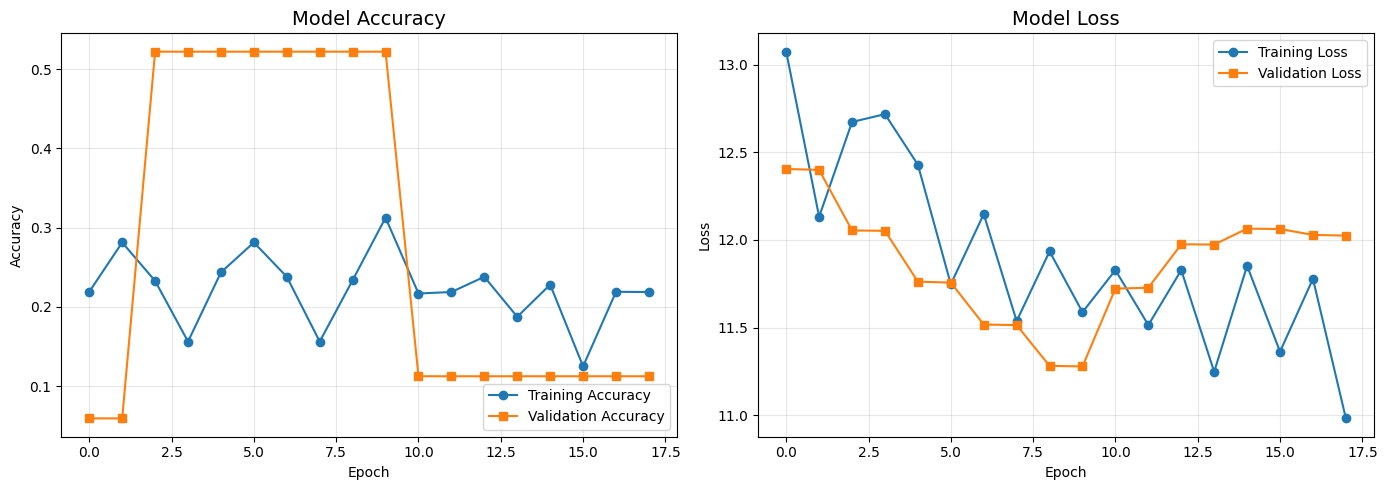

In [ ]:
# =============================================================================
# CELL 20: Plot Training History
# =============================================================================

def plot_training_history(history1, history2=None):
    """Plot training and validation metrics."""

    # Combine histories if two phases
    if history2:
        history = {
            'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
            'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
            'loss': history1.history['loss'] + history2.history['loss'],
            'val_loss': history1.history['val_loss'] + history2.history['val_loss']
        }
    else:
        history = history1.history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history['accuracy'], label='Training Accuracy', marker='o')
    axes[0].plot(history['val_accuracy'], label='Validation Accuracy', marker='s')
    axes[0].set_title('Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history['loss'], label='Training Loss', marker='o')
    axes[1].plot(history['val_loss'], label='Validation Loss', marker='s')
    axes[1].set_title('Model Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_phase1, history_phase2)

In [ ]:
# =============================================================================
# CELL 21: Evaluate on Test Set
# =============================================================================

# =============================================================================
# CELL 21: Evaluate on Test Set (FIXED)
# =============================================================================

print("=" * 60)
print("EVALUATING ON TEST SET")
print("=" * 60)

# Check if best_model.h5 exists and try to load it properly
import os

def load_best_model():
    """Try different methods to load the best model."""

    # Method 1: Try loading the full model (not just weights)
    if os.path.exists('best_model.h5'):
        try:
            print("Attempting to load full model from best_model.h5...")
            loaded_model = tf.keras.models.load_model('best_model.h5', compile=False)
            loaded_model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            print("✅ Successfully loaded full model!")
            return loaded_model
        except Exception as e:
            print(f"❌ Could not load full model: {e}")

    # Method 2: Try loading SavedModel format
    if os.path.exists('diabetic_retinopathy_model'):
        try:
            print("Attempting to load from SavedModel format...")
            loaded_model = tf.keras.models.load_model('diabetic_retinopathy_model', compile=False)
            loaded_model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            print("✅ Successfully loaded SavedModel!")
            return loaded_model
        except Exception as e:
            print(f"❌ Could not load SavedModel: {e}")

    # Method 3: Use the current model in memory (already trained)
    print("ℹ️ Using current model in memory (from training)")
    return None

# Try to load the best model
loaded_model = load_best_model()

# Use loaded model or current model
eval_model = loaded_model if loaded_model is not None else model

print(f"\nUsing model: {type(eval_model)}")

# Reset the test generator
test_gen.reset()

# Calculate number of steps
test_steps = int(np.ceil(len(test_df) / config.BATCH_SIZE))

# Get predictions
print("\nGenerating predictions...")
predictions = eval_model.predict(test_gen, steps=test_steps, verbose=1)

# Get predicted classes
y_pred = np.argmax(predictions, axis=1)

# Get true labels - need to match the number of predictions
y_true = test_df['label_numeric'].values[:len(y_pred)]

print(f"\nPredictions shape: {predictions.shape}")
print(f"y_pred length: {len(y_pred)}")
print(f"y_true length: {len(y_true)}")

# Ensure same length
min_len = min(len(y_pred), len(y_true))
y_pred = y_pred[:min_len]
y_true = y_true[:min_len]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Quadratic Weighted Kappa: {kappa:.4f}")

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

# Get the class names that are actually present in the data
present_classes = sorted(set(y_true) | set(y_pred))
present_class_names = [config.CLASS_NAMES[i] for i in present_classes]

print(classification_report(
    y_true,
    y_pred,
    labels=present_classes,
    target_names=present_class_names,
    zero_division=0
))

EVALUATING ON TEST SET
Attempting to load full model from best_model.h5...
✅ Successfully loaded full model!

Using model: <class 'keras.src.models.functional.Functional'>

Generating predictions...
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step

Predictions shape: (674, 5)
y_pred length: 674
y_true length: 674

TEST SET RESULTS
Test Accuracy: 0.5356 (53.56%)
Quadratic Weighted Kappa: 0.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       No_DR       0.54      1.00      0.70       361
        Mild       0.00      0.00      0.00        74
    Moderate       0.00      0.00      0.00       200
      Severe       0.00      0.00      0.00        39

    accuracy                           0.54       674
   macro avg       0.13      0.25      0.17       674
weighted avg       0.29      0.54      0.37       674



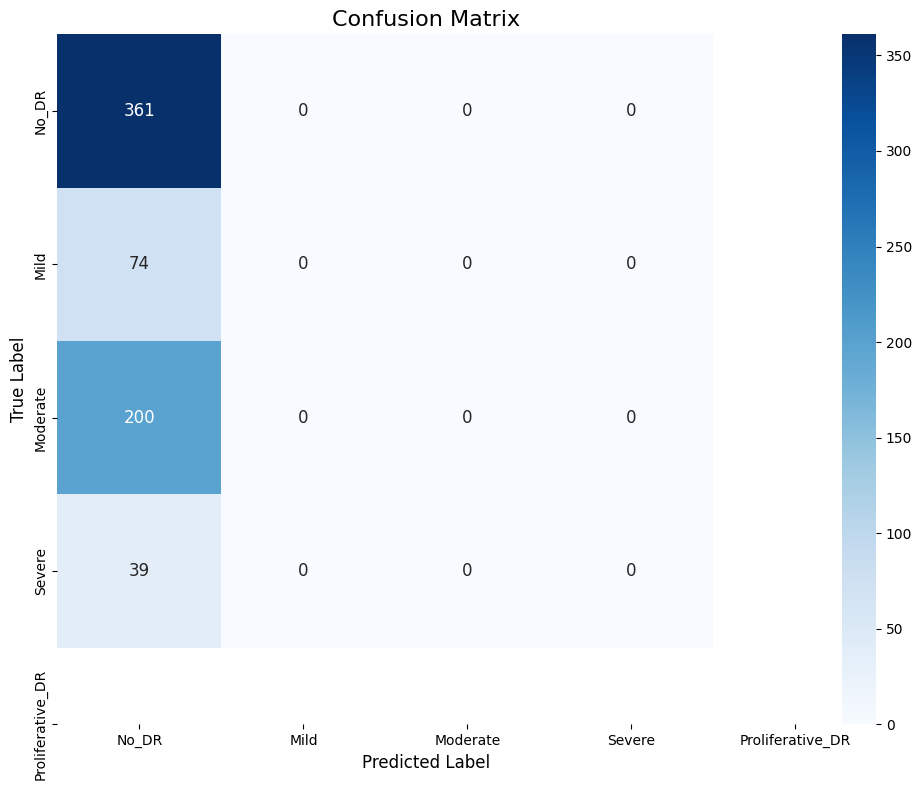

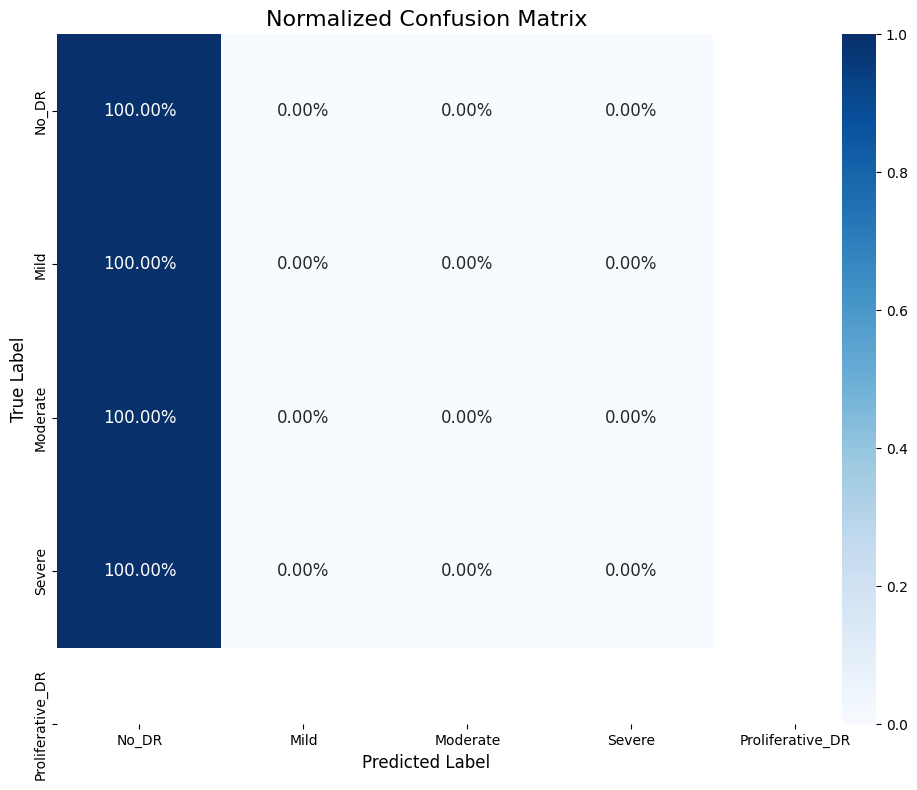

In [ ]:
# =============================================================================
# CELL 22: Confusion Matrix Visualization
# =============================================================================

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={'size': 12}
    )
    plt.title('Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={'size': 12}
    )
    plt.title('Normalized Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_true, y_pred, config.CLASS_NAMES)

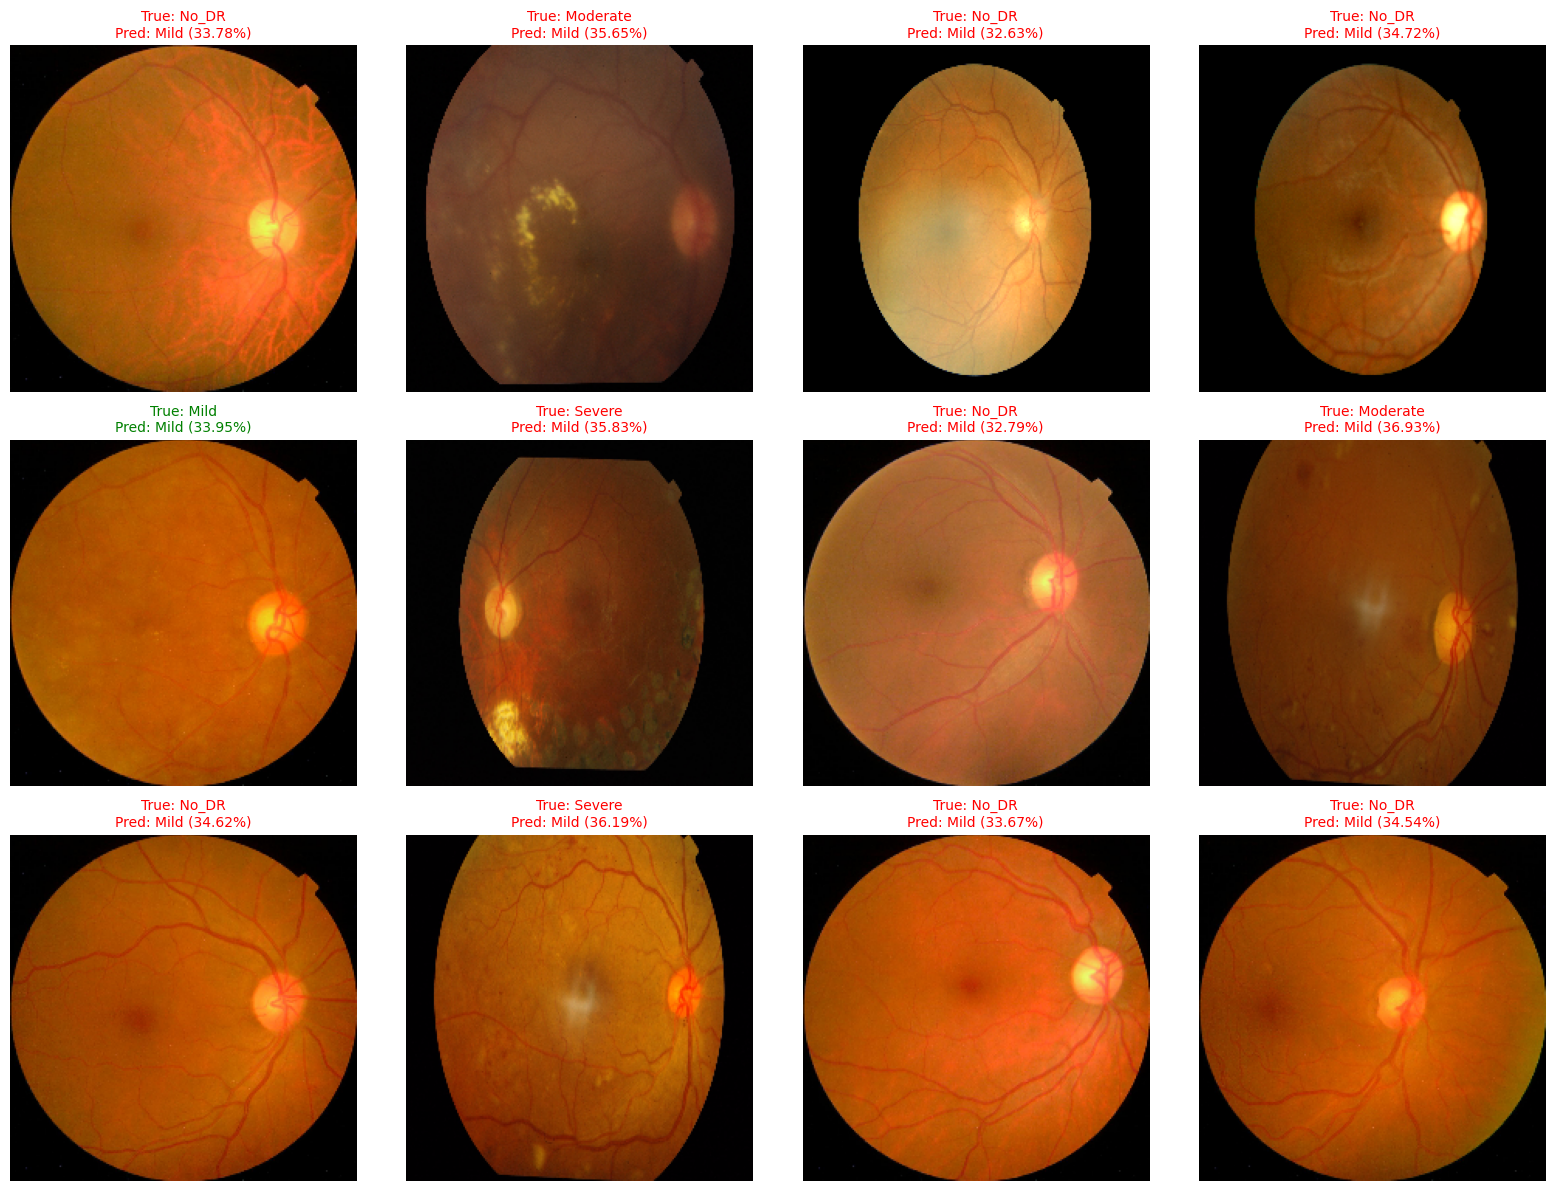

In [ ]:
# =============================================================================
# CELL 24: Visualize Predictions
# =============================================================================

def visualize_predictions(df, model, n_samples=12):
    """Visualize random predictions."""
    sample_df = df.sample(n_samples).reset_index(drop=True)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for idx, row in sample_df.iterrows():
        img = load_and_preprocess_image(row['image_path'])
        if img is None:
            continue

        # Make prediction
        img_batch = np.expand_dims(img, axis=0)
        pred = model.predict(img_batch, verbose=0)
        pred_class = np.argmax(pred[0])
        pred_prob = pred[0][pred_class]
        true_class = int(row['label_numeric'])

        # Determine if correct
        is_correct = pred_class == true_class
        border_color = 'green' if is_correct else 'red'

        axes[idx].imshow(img)
        axes[idx].set_title(
            f"True: {config.CLASS_NAMES[true_class]}\n"
            f"Pred: {config.CLASS_NAMES[pred_class]} ({pred_prob:.2%})",
            fontsize=10,
            color=border_color
        )
        axes[idx].axis('off')

        # Add colored border
        for spine in axes[idx].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

    plt.tight_layout()
    plt.savefig('prediction_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(test_df, model)

No convolutional layer found!
No convolutional layer found!
No convolutional layer found!
No convolutional layer found!


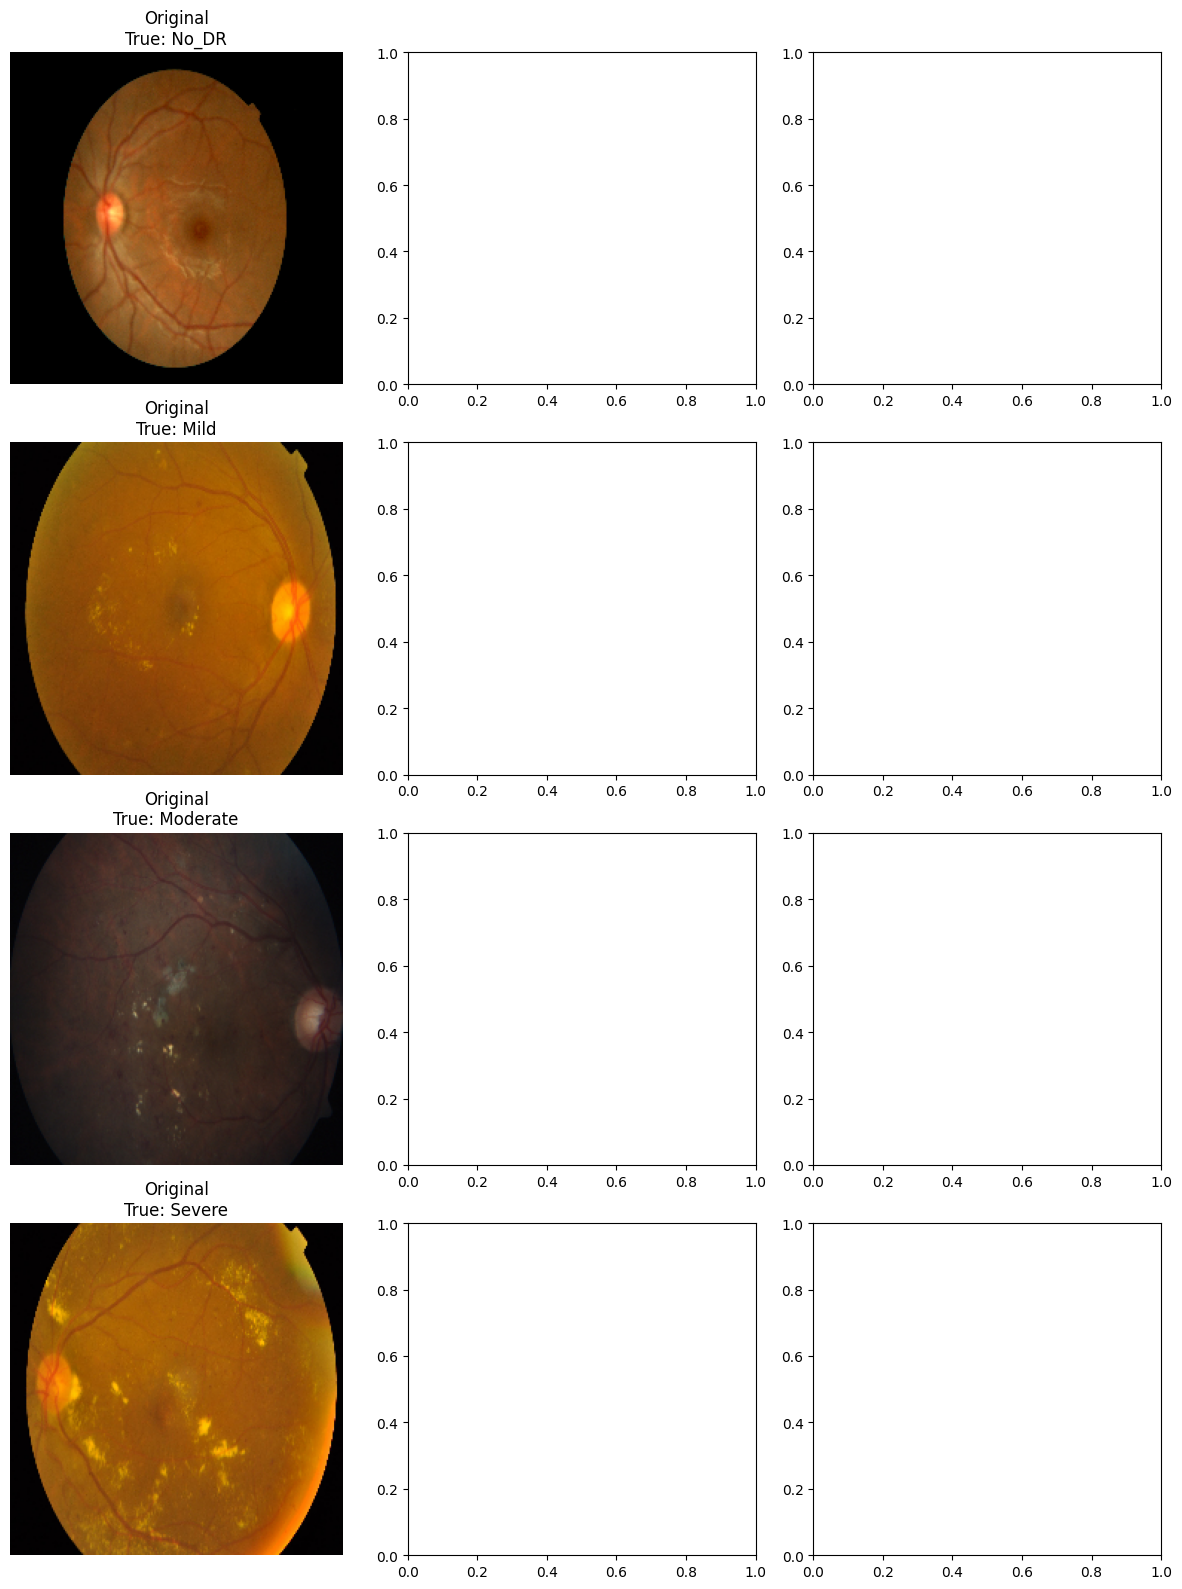

In [ ]:
# =============================================================================
# CELL 25: Grad-CAM Visualization
# =============================================================================

def get_gradcam_heatmap(model, img_array, pred_index=None):
    """Generate Grad-CAM heatmap."""
    # Find the last convolutional layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv_layer = layer
            break

    if last_conv_layer is None:
        print("No convolutional layer found!")
        return None

    # Create gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def visualize_gradcam(model, df, n_samples=4):
    """Visualize Grad-CAM for sample images."""
    sample_df = df.sample(n_samples).reset_index(drop=True)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))

    for idx, row in sample_df.iterrows():
        img = load_and_preprocess_image(row['image_path'])
        if img is None:
            continue

        img_batch = np.expand_dims(img, axis=0)

        # Get prediction
        pred = model.predict(img_batch, verbose=0)
        pred_class = np.argmax(pred[0])
        true_class = int(row['label_numeric'])

        # Get heatmap
        try:
            heatmap = get_gradcam_heatmap(model, img_batch, pred_class)
            if heatmap is not None:
                heatmap = cv2.resize(heatmap, (config.IMG_SIZE, config.IMG_SIZE))
                heatmap = np.uint8(255 * heatmap)
                heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
                heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

                superimposed = cv2.addWeighted(
                    (img * 255).astype(np.uint8), 0.6,
                    heatmap_colored, 0.4, 0
                )
        except Exception as e:
            print(f"Error generating Grad-CAM: {e}")
            heatmap = None
            superimposed = None

        # Plot
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f"Original\nTrue: {config.CLASS_NAMES[true_class]}")
        axes[idx, 0].axis('off')

        if heatmap is not None:
            axes[idx, 1].imshow(heatmap, cmap='jet')
            axes[idx, 1].set_title("Grad-CAM Heatmap")
            axes[idx, 1].axis('off')

            axes[idx, 2].imshow(superimposed)
            axes[idx, 2].set_title(f"Superimposed\nPred: {config.CLASS_NAMES[pred_class]}")
            axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

# Note: Grad-CAM may need adjustment based on model architecture
try:
    visualize_gradcam(model, test_df)
except Exception as e:
    print(f"Grad-CAM visualization failed: {e}")
    print("This is expected for some model architectures.")

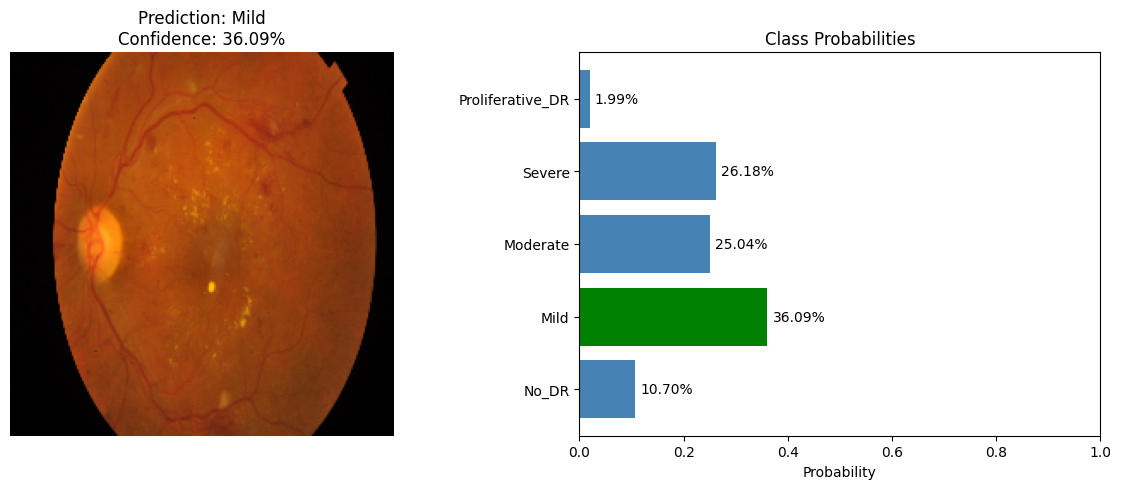


Prediction Result:
  Class: Mild
  Confidence: 36.09%


In [ ]:
# =============================================================================
# CELL 27: Inference Function for New Images
# =============================================================================

def predict_single_image(model, image_path):
    """Make prediction on a single image."""
    # Load and preprocess
    img = load_and_preprocess_image(image_path)
    if img is None:
        print(f"Error loading image: {image_path}")
        return None

    # Make prediction
    img_batch = np.expand_dims(img, axis=0)
    predictions = model.predict(img_batch, verbose=0)
    pred_class = np.argmax(predictions[0])
    confidence = predictions[0][pred_class]

    # Display results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Show image
    axes[0].imshow(img)
    axes[0].set_title(f"Prediction: {config.CLASS_NAMES[pred_class]}\nConfidence: {confidence:.2%}")
    axes[0].axis('off')

    # Show probability distribution
    colors = ['green' if i == pred_class else 'steelblue' for i in range(config.NUM_CLASSES)]
    axes[1].barh(config.CLASS_NAMES, predictions[0], color=colors)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Class Probabilities')
    axes[1].set_xlim(0, 1)

    for i, v in enumerate(predictions[0]):
        axes[1].text(v + 0.01, i, f'{v:.2%}', va='center')

    plt.tight_layout()
    plt.show()

    return {
        'class': config.CLASS_NAMES[pred_class],
        'class_index': pred_class,
        'confidence': confidence,
        'all_probabilities': dict(zip(config.CLASS_NAMES, predictions[0].tolist()))
    }

# Example usage (use a sample from test set)
sample_image = test_df.iloc[0]['image_path']
result = predict_single_image(model, sample_image)
print("\nPrediction Result:")
print(f"  Class: {result['class']}")
print(f"  Confidence: {result['confidence']:.2%}")

In [ ]:
# =============================================================================
# CELL 28: Model Performance Summary
# =============================================================================

def generate_summary_report():
    """Generate a comprehensive summary report."""

    print("=" * 70)
    print("DIABETIC RETINOPATHY DETECTION - MODEL SUMMARY REPORT")
    print("=" * 70)

    print("\n📊 DATASET INFORMATION")
    print("-" * 40)
    print(f"Total images: {len(df)}")
    print(f"Training set: {len(train_df)}")
    print(f"Validation set: {len(val_df)}")
    print(f"Test set: {len(test_df)}")
    print(f"Number of classes: {config.NUM_CLASSES}")
    print(f"Image size: {config.IMG_SIZE}x{config.IMG_SIZE}")

    print("\n🏗️ MODEL ARCHITECTURE")
    print("-" * 40)
    print("Base Model: EfficientNetB3 (ImageNet pretrained)")
    print("Custom Head: GAP → Dense(512) → Dense(256) → Dense(5)")
    print(f"Total parameters: {model.count_params():,}")

    print("\n📈 TRAINING CONFIGURATION")
    print("-" * 40)
    print(f"Batch size: {config.BATCH_SIZE}")
    print(f"Learning rate: {config.LEARNING_RATE}")
    print(f"Total epochs: {config.EPOCHS}")
    print("Optimizer: Adam")
    print("Loss: Sparse Categorical Crossentropy")
    print("Class weighting: Applied")

    print("\n🎯 PERFORMANCE METRICS")
    print("-" * 40)
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Quadratic Weighted Kappa: {kappa:.4f}")

    print("\n📁 SAVED FILES")
    print("-" * 40)
    print("✅ best_model.h5")
    print("✅ diabetic_retinopathy_model.h5")
    print("✅ model_architecture.json")
    print("✅ training_history.png")
    print("✅ confusion_matrix.png")
    print("✅ per_class_analysis.png")

    print("\n" + "=" * 70)
    print("Report generated successfully!")
    print("=" * 70)

generate_summary_report()

DIABETIC RETINOPATHY DETECTION - MODEL SUMMARY REPORT

📊 DATASET INFORMATION
----------------------------------------
Total images: 3367
Training set: 2356
Validation set: 337
Test set: 674
Number of classes: 5
Image size: 224x224

🏗️ MODEL ARCHITECTURE
----------------------------------------
Base Model: EfficientNetB3 (ImageNet pretrained)
Custom Head: GAP → Dense(512) → Dense(256) → Dense(5)
Total parameters: 11,711,284

📈 TRAINING CONFIGURATION
----------------------------------------
Batch size: 32
Learning rate: 0.0001
Total epochs: 30
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Class weighting: Applied

🎯 PERFORMANCE METRICS
----------------------------------------
Test Accuracy: 0.5356 (53.56%)
Quadratic Weighted Kappa: 0.0000

📁 SAVED FILES
----------------------------------------
✅ best_model.h5
✅ diabetic_retinopathy_model.h5
✅ model_architecture.json
✅ training_history.png
✅ confusion_matrix.png
✅ per_class_analysis.png

Report generated successfully!


In [ ]:
# =============================================================================
# CELL 29: Download All Generated Files
# =============================================================================

from google.colab import files
import zipfile

# Create a zip file with all outputs
with zipfile.ZipFile('diabetic_retinopathy_outputs.zip', 'w') as zipf:
    for filename in ['best_model.h5', 'diabetic_retinopathy_model.h5',
                     'model_architecture.json', 'model_weights.h5',
                     'training_history.png', 'confusion_matrix.png',
                     'confusion_matrix_normalized.png', 'per_class_analysis.png',
                     'prediction_samples.png', 'sample_images.png']:
        if os.path.exists(filename):
            zipf.write(filename)

print("All files zipped! Click below to download:")
files.download('diabetic_retinopathy_outputs.zip')

All files zipped! Click below to download:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>